In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [44]:
data = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [45]:
# we want to work with np arrays instead of pandas dataframes
data = np.array(data)
# type(data)
m, n = data.shape # m= no of rows, n= no of cols + 1
np.random.shuffle(data)

data_test = data[0:1000].T # test data
Y_test = data_test[0]
X_test = data_test[1:n]
X_test = X_test / 255

data_train = data[1000:m].T # train data
y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255
_, m_train = X_train.shape

In [46]:
def init_prams():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1)  - 0.5

    return W1, b1, W2, b2

In [47]:
# if the number is > 0, return the exact number if it is < 0, return 0.
def ReLU(Z):
    return np.maximum(Z, 0)

def deriv_ReLU(Z):
    return Z > 0

# softmax converts a vector into a probability distribution of values (b/w 0&1) that add upto 1.
def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

In [48]:
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1 # Z1 = W1*X + b1 this is the neuron function of the first hidden layer
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2 # Z2 = W2*A1 + b2 is the neuron function of the second/output layer
    A2 = softmax(Z2)
    
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    
    return one_hot_Y
    
def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

In [49]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

In [50]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2

    return W1, b1, W2, b2

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_prams()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        
        # print this every 10th iteration 
        if (i % 100 == 0):
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
            
    return W1, b2, W2, b2

In [51]:
W1, b1, W2, b2 = gradient_descent(X_train, y_train, iterations= 3000, alpha= 0.1)

Iteration:  0
[7 7 7 ... 7 7 7] [6 9 0 ... 1 3 3]
Accuracy:  0.10353658536585365
Iteration:  100
[6 9 0 ... 1 6 8] [6 9 0 ... 1 3 3]
Accuracy:  0.6146829268292683
Iteration:  200
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.7447560975609756
Iteration:  300
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.7912682926829269
Iteration:  400
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.8149756097560975
Iteration:  500
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.8312926829268292
Iteration:  600
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.8421951219512195
Iteration:  700
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.851170731707317
Iteration:  800
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.857780487804878
Iteration:  900
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.8634390243902439
Iteration:  1000
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.868390243902439
Iteration:  1100
[6 9 0 ... 1 2 3] [6 9 0 ... 1 3 3]
Accuracy:  0.8723170731707317
Iteration:  1200
[

In [52]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [6]
Label:  6


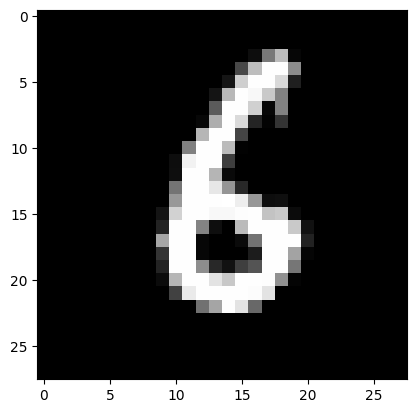

In [53]:
# testing examples

test_prediction(7, W1, b1, W2, b2)

In [54]:
dev_predictions= make_predictions(X_test, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_test)

# 82% accuracy on test data with 500 iterations
# 88% accuracy on test data with 3000 iterations, converging at a 90% accurcay of trianing data.

[0 0 2 1 6 4 9 3 5 8 4 8 5 9 7 4 6 0 2 8 1 8 6 6 7 0 6 7 4 6 3 2 0 4 2 1 3
 6 5 9 5 8 8 5 8 5 3 4 9 1 2 6 8 4 0 1 2 6 8 2 3 1 7 9 8 8 4 2 8 4 1 0 5 2
 5 1 0 2 6 7 4 5 2 9 7 2 5 7 3 2 4 9 3 3 6 7 2 2 6 4 9 1 1 3 6 4 6 3 2 3 2
 4 0 6 1 5 9 8 2 1 2 6 9 7 8 3 1 0 8 5 3 3 5 0 2 0 0 8 8 9 5 6 2 3 3 9 7 7
 5 9 6 2 1 2 6 7 5 8 7 7 6 0 4 8 6 3 1 1 1 7 4 1 4 5 9 5 1 2 2 6 7 6 8 2 3
 6 3 5 0 3 8 5 0 3 2 9 2 7 2 7 3 2 0 2 2 1 8 1 9 3 0 5 0 0 5 6 4 3 2 2 7 5
 3 8 8 2 3 5 6 3 3 9 5 8 0 4 9 5 6 4 4 2 4 4 6 9 6 0 5 9 3 1 6 0 3 8 9 1 4
 5 9 8 4 6 8 8 0 8 9 7 6 1 4 5 9 9 3 6 9 4 4 6 2 7 3 8 0 7 2 0 7 0 6 3 0 1
 9 5 6 0 6 6 4 4 3 5 8 2 3 7 4 5 0 9 9 9 2 8 5 7 9 9 0 7 4 3 2 4 4 9 5 3 9
 5 4 7 5 5 2 0 5 9 0 7 8 3 4 5 6 1 2 9 5 8 7 0 6 5 5 0 6 3 4 8 1 3 5 1 7 7
 0 6 1 6 6 8 0 5 9 3 3 3 6 6 4 1 3 9 9 7 2 7 3 1 1 6 0 8 0 1 5 9 9 4 3 2 0
 3 1 7 6 9 8 2 4 6 6 8 4 5 0 2 8 1 7 9 8 9 3 4 8 9 1 8 5 7 5 4 0 5 1 3 4 9
 7 1 5 8 0 9 0 9 4 4 6 6 6 2 0 9 5 1 4 5 7 2 7 8 1 0 4 2 9 7 4 1 1 8 9 9 7
 4 4 7 7 0 6 2 8 5 7 3 7 

np.float64(0.881)

In [55]:
predictions = make_predictions(X_test, W1, b1, W2, b2)
cm = confusion_matrix(Y_test, predictions)

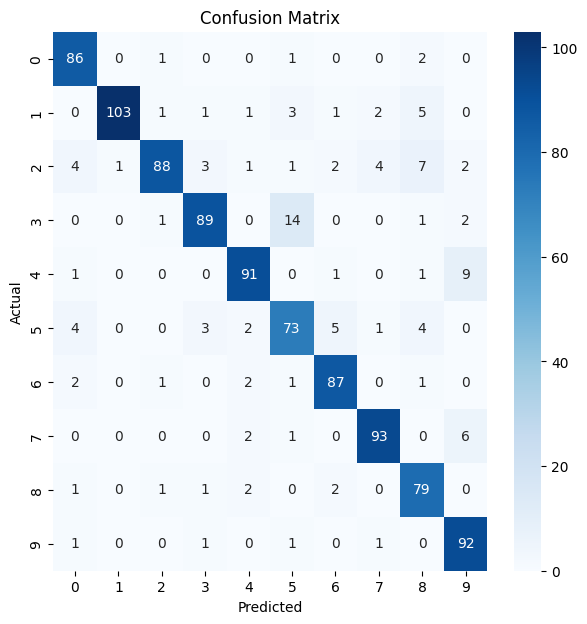

In [56]:
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [57]:
from collections import Counter

print("Actual 5s:", np.sum(Y_test == 5))
print("Actual 9s:", np.sum(Y_test == 9))

Actual 5s: 92
Actual 9s: 96


In [58]:
# accuray of recognition for each individual digit

for digit in range(10):
    mask = Y_test == digit
    
    accuracy = np.mean(predictions[mask] == Y_test[mask])

    print(f"{digit}: {accuracy * 100:.2f}%")

0: 95.56%
1: 88.03%
2: 77.88%
3: 83.18%
4: 88.35%
5: 79.35%
6: 92.55%
7: 91.18%
8: 91.86%
9: 95.83%


In [67]:
np.savez(
    "mnist_parameters.npz",
    W1=W1,
    b1=b1,
    W2=W2,
    b2=b2
)